In [1]:
import os
import copy
import numpy as np
import scipy.io as sio
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils import calculate_mcc, min_max_aggregate, convert_pvalue_to_asterisks

In [2]:
def reshape_loss(loss, n_co = 11):
    n_iter_per_co = loss.shape[0]
    loss_list = []
    n_epoch_list = []
    for i in range(n_co):
        if 0 in loss[:,i]:
            ind_zero = np.where(loss[:,i] == 0)[0][0]
            loss_list.append(loss[:ind_zero, i])
            n_epoch_list.append(ind_zero)
        else:
            loss_list.append(loss[:, i])
            n_epoch_list.append(n_iter_per_co)
    return loss_list, n_epoch_list

def load_data(datadir, ss_dir, ss_key, init_wf, num_comopt = 11):
    loss = sio.loadmat(os.path.join(datadir,ss_dir,f"loss.mat"))[f"loss_{init_wf}"]
    loss_list, n_epoch_list = reshape_loss(loss, num_comopt)
    aux = sio.loadmat(os.path.join(datadir,ss_dir,f"aux.mat"))

    if ss_key != "s5":    
        Y = np.squeeze(aux[f"aux_{init_wf}"][3,:])
        t = np.squeeze(sio.loadmat(os.path.join(datadir,ss_dir,f"time.mat"))[f"t_{init_wf}"])
        isi = np.squeeze(sio.loadmat(os.path.join(datadir,ss_dir,"isi.mat"))[f"isi_{init_wf}"])
        isi_min = min(isi)
        isi_ind = np.argmin(isi)
        isi_test = np.squeeze(sio.loadmat(os.path.join(datadir,ss_dir,"MISI_Stest.mat"))[f"isi_{init_wf}"])
        isi_test_min = min(isi_test)
        a = np.squeeze(aux[f"aux_{init_wf}"][1,:])
        final_loss = np.array([a[k][0][0] for k in range(num_comopt)])
        final_loss_min = final_loss[isi_ind]
    else:
        Y = aux[f"aux_{init_wf}"][3,:]
        t = sio.loadmat(os.path.join(datadir,ss_dir,f"time.mat"))[f"t_{init_wf}"][0,0]
        isi = sio.loadmat(os.path.join(datadir,ss_dir,"isi.mat"))[f"isi_{init_wf}"][0,0]
        isi_min = isi
        isi_test = sio.loadmat(os.path.join(datadir,ss_dir,"MISI_Stest.mat"))[f"isi_{init_wf}"][0,0]
        isi_test_min = isi_test
        final_loss = aux[f"aux_{init_wf}"][1,0][0,0]
        final_loss_min = final_loss
        
    return Y, loss_list, n_epoch_list, t, isi, isi_min, isi_test, isi_test_min, final_loss, final_loss_min

def plot_loss(ax, loss_list, loss_min_min, n_epoch_list, isi, isi_test, mcc_list, md_list, mcc_gt, md_gt, title, ss="S5", lowest_isi=False, lowest_isi_test=False, legend=False, xlabel=True):
    colors=plt.cm.Set3
    loss = np.hstack(loss_list)
    ind_loss = np.argmin(loss)
    epoch_boundaries = np.cumsum(n_epoch_list)
    normalized_loss_list = []
    start = 0
    for i, end in enumerate(epoch_boundaries):
        ax.axvspan(start, end, color=colors(i), alpha=0.3)
        normalized_loss = loss_list[i] - loss_min_min + np.sqrt(np.finfo(np.float32).eps)
        normalized_loss_list.append(normalized_loss)
        ax.plot(range(start, end), normalized_loss, color='dimgray', linewidth=2)
        start = end
    normalized_loss_all = np.hstack(normalized_loss_list)
    ax.plot(ind_loss, normalized_loss_all[ind_loss], 'd', color='k', markersize=4, alpha=0.6, label="Lowest normalized loss")
    ax.set_title(title, fontsize=14) #, fontweight='bold'
    ax.set_xlim(-50, 1700) # 150 iterations
    ax.set_ylim(1e-4, 50) # log scale, not divide by data entropy
    ax.set_yscale('log')
    if xlabel:
        ax.set_xlabel('Numerical optimization iteration', fontsize=11)
    ax.set_ylabel('Normalized loss', fontsize=11)
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    ax2 = ax.twinx()
    ax2.plot(epoch_boundaries, isi_test, '*', color='forestgreen', markersize=6, alpha=0.7, label="MISI with $S^{{Test}}$")
    ind_test = np.argmin(isi_test)
    ax2.plot(epoch_boundaries, isi, '*', color='orangered', markersize=6, alpha=0.7, label="MISI with $S^{{GT}}$")
    ind = np.argmin(isi)
    if lowest_isi_test:
        isi_test_marker = 's'
    else:
        isi_test_marker = 'o'
    if lowest_isi:
        isi_marker = 's'
    else:
        isi_marker = 'o'
    if ss == "s5":
        ax2.plot(epoch_boundaries, isi_test, isi_test_marker, color='forestgreen', markersize=7, markerfacecolor="None")
        ax2.plot(epoch_boundaries, isi, isi_marker, color='orangered', markersize=7, markerfacecolor="None")#, label="Lowest value across all initialization workflows"
    else:
        ax2.plot(epoch_boundaries[ind_test], isi_test[ind_test], isi_test_marker, color='forestgreen', markersize=7, markerfacecolor="None")
        ax2.plot(epoch_boundaries[ind], isi[ind], isi_marker, color='orangered', markersize=7, markerfacecolor="None")#, label="Lowest value across all initialization workflows"
    ax2.tick_params(axis='both', which='major', labelsize=9)

    mcc_labels = ['1 - MMCC', '1 - CMCC']
    md_labels = ['MMD', 'CMD']
    shape_list = ['o', 's']
    for i, mcc in enumerate(mcc_list):
        ax2.plot(epoch_boundaries, mcc, shape_list[i], color='cornflowerblue', markersize=5, alpha=0.7, label=mcc_labels[i])
    ax2.axhline(y=1-mcc_gt, color='cornflowerblue', linestyle='--', zorder=1, label='1 - CMCC on GT sources')
    for i, md in enumerate(md_list):
        ax2.plot(epoch_boundaries, md, shape_list[i], color='orange', markersize=5, alpha=0.7, label=md_labels[i])
    ax2.axhline(y=md_gt, color='orange', linestyle='--', zorder=1, label='CMD on GT sources')
    ax2.axhline(y=0.1, color='gray', linestyle='-.', zorder=1)
    ax2.axhline(y=0.01, color='gray', linestyle='-.', zorder=1)
    ax2.set_ylim(1e-3, 2)
    ax2.set_yscale('log')
    ax2.set_ylabel('MISI / 1-MCC / MD', fontsize=11)
    if legend:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=7) #bbox_to_anchor=(1.16, 0.9)

    return normalized_loss_list

In [ ]:
n_iter = 150
outdir = f"sim_iter{n_iter}_v20k_snr1k"
datadir = f"/data/users4/xli/MSIVA/MSIVA/results/{outdir}"
subspace_dict = {"s1": [2, 3, 4], "s2": [2, 2, 2, 2, 2], "s3": [3, 3, 3], "s4": [4, 4], "s5": [1]*12}

loss_all_dict = {}
normalized_loss_all_dict = {}
n_epoch_all_dict = {}
t_all_dict = {}
isi_all_dict = {}
isi_min_all_dict = {}
isi_min_bool_all_dict = {}
isi_test_all_dict = {}
isi_test_min_all_dict = {}
isi_test_min_bool_all_dict = {}
final_loss_all_dict = {}
final_loss_min_all_dict = {}
mcc_all_dict = {}
md_all_dict = {}
loss_min_all_dict = {"s1": {}, "s2": {}, "s3": {}, "s4": {}, "s5": {}}
loss_min_min_all_dict = {"s1": {}, "s2": {}, "s3": {}, "s4": {}, "s5": {}}

# fig, raxes = plt.subplots(nrows=3, ncols=5, figsize=(15, 9))

for ss_id, ss_key in enumerate(subspace_dict.keys()):
    for tss_id, tss_key in enumerate(subspace_dict.keys()):
        output_path = f"loss/{outdir}_mmcc/loss_gt_{ss_key}_test_{tss_key}.pdf"
        gtss_dir = f"gt_{ss_key}_test_{ss_key}"
        ss_dir = f"gt_{ss_key}_test_{tss_key}"
        print(ss_dir)
        
        if tss_key != "s5":
            num_comopt = 11 
        else:
            num_comopt = 1
        
        ss = subspace_dict[ss_key]
        
        Y_gt = np.squeeze(sio.loadmat(os.path.join(datadir,gtss_dir,"Ygt.mat"))["Y"])

        Y_um, loss_um, n_epoch_um, t_um, isi_um, isi_min_um, isi_test_um, isi_test_min_um, final_loss_um, final_loss_min_um = load_data(datadir, ss_dir, tss_key, "um", num_comopt)
        Y_ummm, loss_ummm, n_epoch_ummm, t_ummm, isi_ummm, isi_min_ummm, isi_test_ummm, isi_test_min_ummm, final_loss_ummm, final_loss_min_ummm = load_data(datadir, ss_dir, tss_key, "ummm", num_comopt)
        Y_mm, loss_mm, n_epoch_mm, t_mm, isi_mm, isi_min_mm, isi_test_mm, isi_test_min_mm, final_loss_mm, final_loss_min_mm = load_data(datadir, ss_dir, tss_key, "mm", num_comopt)

        corr_gt = np.corrcoef(Y_gt[0],Y_gt[1])[12:,:12]
        mcc_gt, md_gt, aggcorr_gt, col_order_gt = calculate_mcc(corr_gt, ss)

        Y_dict = {"um": Y_um, "ummm": Y_ummm, "mm": Y_mm}
        loss_dict = {"um": loss_um, "ummm": loss_ummm, "mm": loss_mm}
        n_epoch_dict = {"um": n_epoch_um, "ummm": n_epoch_ummm, "mm": n_epoch_mm}
        t_dict = {"um": t_um, "ummm": t_ummm, "mm": t_mm}
        isi_dict = {"um": isi_um, "ummm": isi_ummm, "mm": isi_mm}
        isi_min_dict = {"um": isi_min_um, "ummm": isi_min_ummm, "mm": isi_min_mm}
        isi_test_dict = {"um": isi_test_um, "ummm": isi_test_ummm, "mm": isi_test_mm}
        isi_test_min_dict = {"um": isi_test_min_um, "ummm": isi_test_min_ummm, "mm": isi_test_min_mm}
        final_loss_dict = {"um": final_loss_um, "ummm": final_loss_ummm, "mm": final_loss_mm}
        final_loss_min_dict = {"um": final_loss_min_um, "ummm": final_loss_min_ummm, "mm": final_loss_min_mm}

        mcc_dict = {"um": [[], []], "ummm": [[], []], "mm": [[], []]}
        md_dict = {"um": [[], []], "ummm": [[], []], "mm": [[], []]}

        for j, key in enumerate(Y_dict.keys()):
            Y = Y_dict[key]
            for i in range(num_comopt):
                corr1 = np.corrcoef(Y_gt[0],Y[i][0,0])[12:,:12]
                corr2 = np.corrcoef(Y_gt[1],Y[i][0,1])[12:,:12]
                corr3 = np.corrcoef(Y[i][0,0],Y[i][0,1])[12:,:12]
                mcc1, md1, aggcorr1, col_order1 = calculate_mcc(corr1, ss)
                mcc2, md2, aggcorr2, col_order2 = calculate_mcc(corr2, ss, True, col_order1)
                mcc3, md3, aggcorr3, col_order3 = calculate_mcc(corr3, ss, False, None)
                aggcorr = min_max_aggregate(aggcorr1, aggcorr2)
                mmcc = np.mean(np.diag(aggcorr))
                off_diag_ind = ~np.eye(aggcorr.shape[0], dtype=bool)
                mmd = (np.sum(aggcorr[off_diag_ind]) + np.sum(1-np.diag(aggcorr)))/(len(ss)**2)

                mcc_dict[key][0].append(1-mmcc) # MMCC
                mcc_dict[key][1].append(1-mcc3) # CMCC
                md_dict[key][0].append(mmd) # MMD
                md_dict[key][1].append(md3) # CMD

            # if ss_key == tss_key:
            #     raxes[j, ss_id].imshow(corr3)
            #     raxes[j, ss_id].axis('off')
            #     raxes[j, ss_id].set_title(f"{ss_key} {key}", fontsize=12)
        # print(f"ISI unimodal: {isi_min_um}; msiva: {isi_min_ummm}; multimodal: {isi_min_mm}")
        # print(f"Final loss unimodal: {final_loss_min_um}; msiva: {final_loss_min_ummm}; multimodal: {final_loss_min_mm}")

        def get_isi_min(isi_min_um, isi_min_ummm, isi_min_mm):
            isi_min = min(np.hstack([isi_min_um, isi_min_ummm, isi_min_mm]))
            ind_isi_min = np.argmin([isi_min_um, isi_min_ummm, isi_min_mm])
            # print(f"Lowest ISI: {isi_min}, workflow index: {ind_isi_min}")
            is_min_um = isi_min_um == isi_min
            is_min_ummm = isi_min_ummm == isi_min
            is_min_mm = isi_min_mm == isi_min
            is_min_dict = {"um": is_min_um, "ummm": is_min_ummm, "mm": is_min_mm}
            return is_min_dict

        k = f"gt_{ss_key}_test_{tss_key}"
        loss_all_dict[k] = loss_dict
        n_epoch_all_dict[k] = n_epoch_dict
        t_all_dict[k] = t_dict
        isi_all_dict[k] = isi_dict
        isi_min_all_dict[k] = isi_min_dict
        isi_min_bool_all_dict[k] = get_isi_min(isi_min_um, isi_min_ummm, isi_min_mm)
        isi_test_all_dict[k] = isi_test_dict
        isi_test_min_all_dict[k] = isi_test_min_dict
        isi_test_min_bool_all_dict[k] = get_isi_min(isi_test_min_um, isi_test_min_ummm, isi_test_min_mm)
        final_loss_all_dict[k] = final_loss_dict
        final_loss_min_all_dict[k] = final_loss_min_dict
        mcc_all_dict[k] = mcc_dict
        md_all_dict[k] = md_dict
        
    for k in ["um", "ummm", "mm"]:
        loss_min_all_dict[ss_key][k] = np.array([np.min(np.hstack(loss_all_dict[f"gt_{ss_key}_test_{tss_key}"][k])) for tss_key in subspace_dict.keys()])
        loss_min_min_all_dict[ss_key][k] = np.min(loss_min_all_dict[ss_key][k])
    
    # if os.path.exists(output_path):
    #     continue

    for i, tss_key in enumerate(subspace_dict.keys()):
        output_path = f"loss/{outdir}/loss_gt_{ss_key}_test_{tss_key}.pdf"
        # if os.path.exists(output_path):
        #     continue
        if tss_key != "s5":
            show_legend = False
        else:
            show_legend = True
        
        k = f"gt_{ss_key}_test_{tss_key}"
        loss_min_um = loss_min_all_dict[ss_key]["um"][i]
        loss_min_ummm = loss_min_all_dict[ss_key]["ummm"][i]
        loss_min_mm = loss_min_all_dict[ss_key]["mm"][i]
        t_um = t_all_dict[k]["um"]
        t_ummm = t_all_dict[k]["ummm"]
        t_mm = t_all_dict[k]["mm"]
        fig, axes = plt.subplots(3, 1, figsize=(5.5, 6.5))
        normalized_loss_um = plot_loss(axes[0], loss_all_dict[k]["um"], loss_min_min_all_dict[ss_key]["um"], n_epoch_all_dict[k]["um"], isi_all_dict[k]["um"], isi_test_all_dict[k]["um"], mcc_all_dict[k]["um"], md_all_dict[k]["um"], mcc_gt, md_gt, f"Unimodal initialization  T={t_um/60:.2f}min", tss_key, isi_min_bool_all_dict[k]["um"], isi_test_min_bool_all_dict[k]["um"], False, False)#$S_{ss_id+1}^{{GT}}$ $S_{i+1}^{{Test}}$
        normalized_loss_ummm = plot_loss(axes[1], loss_all_dict[k]["ummm"], loss_min_min_all_dict[ss_key]["ummm"], n_epoch_all_dict[k]["ummm"], isi_all_dict[k]["ummm"], isi_test_all_dict[k]["ummm"], mcc_all_dict[k]["ummm"], md_all_dict[k]["ummm"], mcc_gt, md_gt, f"Default initialization  T={t_ummm/60:.2f}min", tss_key, isi_min_bool_all_dict[k]["ummm"], isi_test_min_bool_all_dict[k]["ummm"], False, False)
        normalized_loss_mm = plot_loss(axes[2], loss_all_dict[k]["mm"], loss_min_min_all_dict[ss_key]["mm"], n_epoch_all_dict[k]["mm"], isi_all_dict[k]["mm"], isi_test_all_dict[k]["mm"], mcc_all_dict[k]["mm"], md_all_dict[k]["mm"], mcc_gt, md_gt, f"Multimodal initialization  T={t_mm/60:.2f}min", tss_key, isi_min_bool_all_dict[k]["mm"], isi_test_min_bool_all_dict[k]["mm"], show_legend, True)
        plt.tight_layout()
        plt.savefig(output_path)
        plt.close()

        normalized_loss_all_dict[k] = {"um": normalized_loss_um, "ummm": normalized_loss_ummm, "mm": normalized_loss_mm}

gt_s1_test_s1
gt_s1_test_s2
gt_s1_test_s3
gt_s1_test_s4
gt_s1_test_s5
gt_s2_test_s1
gt_s2_test_s2
gt_s2_test_s3
gt_s2_test_s4
gt_s2_test_s5
gt_s3_test_s1
gt_s3_test_s2
gt_s3_test_s3
gt_s3_test_s4
gt_s3_test_s5
gt_s4_test_s1
gt_s4_test_s2
gt_s4_test_s3
gt_s4_test_s4
gt_s4_test_s5
gt_s5_test_s1
gt_s5_test_s2
gt_s5_test_s3
gt_s5_test_s4
gt_s5_test_s5


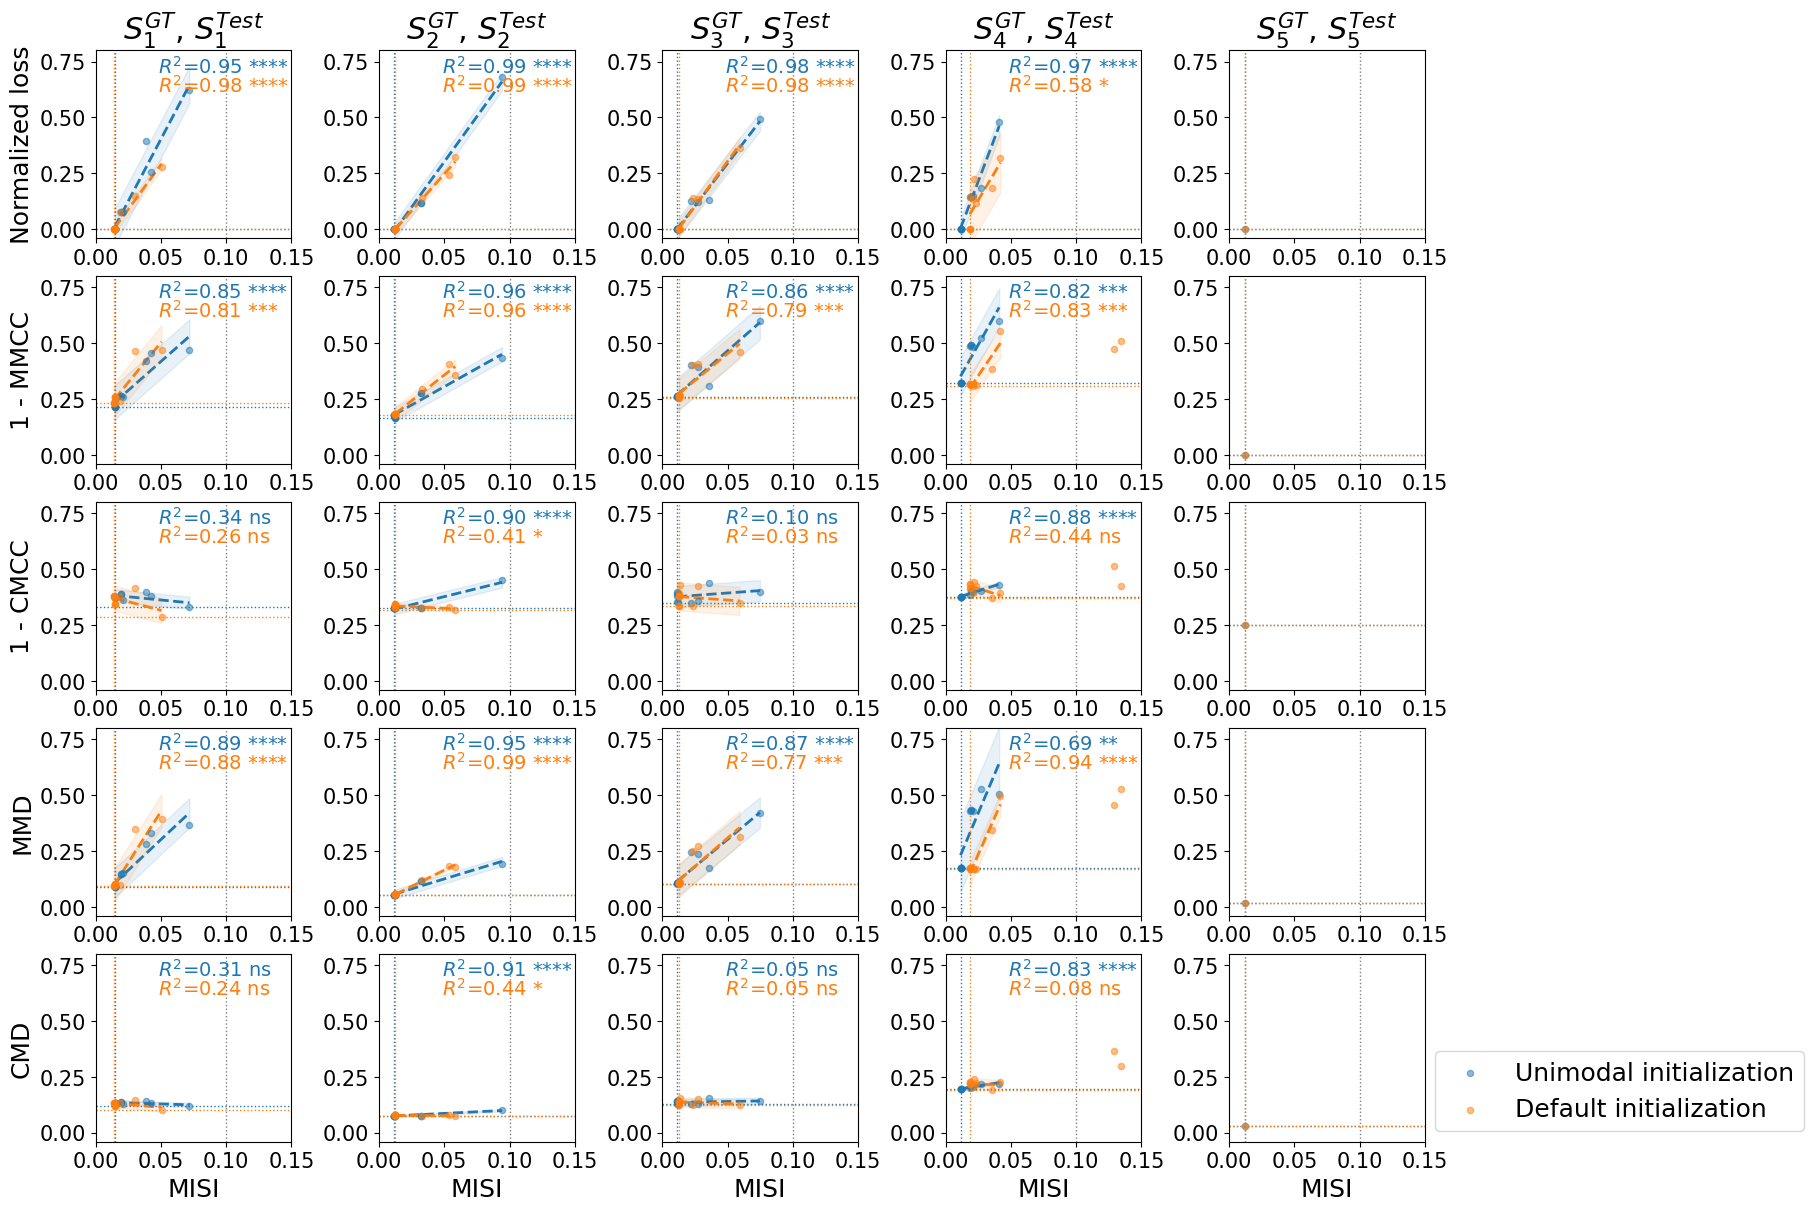

In [ ]:
misi_dict, loss_dict, mmcc_dict, cmcc_dict, mmd_dict, cmd_dict, color_dict, label_dict = {}, {}, {}, {}, {}, {}, {}, {}
init_list = ["Unimodal", "Default"]
ylabel_list = ["Normalized loss", "1 - MMCC", "1 - CMCC", "MMD", "CMD"]

fig, axes = plt.subplots(5, 5, figsize=(18, 12), layout='constrained')
cmap = mpl.colormaps['tab10']

for ss_id, ss_key in enumerate(subspace_dict.keys()):
    tss_key = ss_key
    k = f"gt_{ss_key}_test_{tss_key}"
    misi_all, loss_all, mmcc_all, cmcc_all, mmd_all, cmd_all, color_list, label_list = [], [], [], [], [], [], [], []
    for i, init in enumerate(['um','ummm']):
        if tss_key != "s5":
            misi_list = list(isi_all_dict[k][init])
        else:
            misi_list = [isi_all_dict[k][init]]
        misi_all += misi_list
        loss_list = [loss[-1] for loss in normalized_loss_all_dict[k][init]]
        loss_all += loss_list
        mmcc_list = mcc_all_dict[k][init][0]
        mmcc_all += mmcc_list
        cmcc_list = mcc_all_dict[k][init][1]
        cmcc_all += cmcc_list
        mmd_list = md_all_dict[k][init][0]
        mmd_all += mmd_list
        cmd_list = md_all_dict[k][init][1]
        cmd_all += cmd_list
        n = len(loss_list)
        color_list += [cmap(i)] * n
        label_list += [f"{init_list[i]} initialization"] * n
    
    metric_list = [loss_all, mmcc_all, cmcc_all, mmd_all, cmd_all]
    for id, metric in enumerate(metric_list):
        ax = axes[id, ss_id]
        ylim = [-0.04, 0.8]
        ax.vlines(0.1, ylim[0], ylim[1], colors="gray", linestyles=':', linewidth=1, zorder=1)
        _, color_indices = np.unique(color_list, axis=0, return_index=True)
        unique_colors = [color_list[index] for index in sorted(color_indices)]
        for c, color in enumerate(unique_colors):
            mask = np.all(np.array(color_list) == color, axis=1)
            unique_label = np.array(label_list)[mask][0]
            x_unsorted = np.array(misi_all)[mask]
            y_unsorted = np.array(metric)[mask]
            
            sorted_indices = x_unsorted.argsort()
            x = x_unsorted[sorted_indices]
            y = y_unsorted[sorted_indices]

            ax.scatter(x, y, color=color, label=unique_label, s=20, alpha=0.5, zorder=2)
            ax.vlines(min(x), ylim[0], ylim[1], colors=color, linestyles=':', linewidth=1, zorder=1)
            ax.hlines(min(y), 0, 0.15, colors=color, linestyles=':', linewidth=1, zorder=1)

            if tss_key == "s5":
                continue
            ind = x <= 0.1
            # Fit a linear line
            slope, intercept, r, p, std_err = stats.linregress(x[ind], y[ind])
            # Line of best fit
            line = slope * x[ind] + intercept
            ax.plot(x[ind], line, linestyle='--', color=color, linewidth=2, zorder=1)
            # Calculate prediction intervals (approximate)
            residuals = y[ind] - line
            mse = np.mean(residuals**2)
            std_residuals = np.sqrt(mse)
            # Simple confidence interval (±2 standard errors)
            confidence_interval = 2 * std_residuals
            ax.fill_between(x[ind], line - confidence_interval, line + confidence_interval, alpha=0.1, color=color, zorder=1)
            sig_level = convert_pvalue_to_asterisks(p)
            r_sq = r**2
            if id == 0:
                y_text = (0.74 - 0.085*c)/0.84*(ylim[1]-ylim[0])+ylim[0]
                ax.text(0.048, y_text, f"$R^2$={r_sq:.2f} {sig_level}", fontsize=14, color=color, zorder=3)
            else:
                y_text = 0.7 - 0.085*c
                ax.text(0.048, y_text, f"$R^2$={r_sq:.2f} {sig_level}", fontsize=14, color=color, zorder=4)
        if id == 0:
            ax.set_title(f"$S_{ss_id+1}^{{GT}}$, $S_{ss_id+1}^{{Test}}$", fontsize=22)
        if id == 4:
            ax.set_xlabel("MISI", fontsize=18)
        if ss_id == 0:
            ax.set_ylabel(ylabel_list[id], fontsize=18)
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.set_xlim([0, 0.15])
        ax.set_ylim(ylim)
        if ss_id == 4 and id == 4:
            ax.legend(bbox_to_anchor=(3, 0.55), fontsize=18)

plt.savefig("figures/appendix_scatter_plots.pdf", bbox_inches='tight')